# Fig 2


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.font_manager import FontProperties
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["figure.figsize"] = [3, 4]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["svg.fonttype"] = "none"

font = FontProperties()
font.set_family("serif")
font.set_name("Times New Roman")

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]
sns.set(style="white")
sns.set_context("paper", rc={"font.size": 6, "axes.titlesize": 8, "axes.labelsize": 8})

colorcity_short = {
    "Sao Paulo": "#19967d",
    "Hong Kong": "#3bc0cf",
    "Chicago": "#fdb528",
    "London": "#0c7cba",
    "Boston": "#ef5c43",
}
city_short_order = ["Boston", "Chicago", "Hong Kong", "London", "Sao Paulo"]


def resolve_data_path() -> Path:
    candidates = [
        Path.cwd() / "data" / "c_individual_all.parquet",
        Path.cwd().parent / "data" / "c_individual_all.parquet",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find data/c_individual_all.parquet")


def style_axis(ax, percent_y=True):
    ax.grid(visible=True, which="major", axis="both", linestyle="--", linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")
    if percent_y:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontproperties(font)


DATA_PATH = resolve_data_path()
DATA_PATH


PosixPath('/Users/yuan/Dropbox (Personal)/Personal Work/_Projects_GIT/social-mixing-5-city/data/c_individual_all.parquet')

In [2]:
hhcount = 5
activity_ls = ["employed", "student", "parttime", "homemaker", "retired", "unemployed"]

y_labels = {
    "mixing_primary": "Daytime Social Mixing Index",
}
x_labels = {
    "hhIncomeQ_4": "Income Groups (4)",
    "ageGroup_structure": "Age Groups",
    "hh_mem_class": "Household Size",
    "with_car_label": "Car Ownership",
    "home_dist_center_poly_cat": "Distance to Main Transit Centers",
}
figsize_dict = {
    "hhIncomeQ_4": (3, 3),
    "ageGroup_structure": (3.5, 3),
    "hh_mem_class": (3, 3),
    "with_car_label": (3, 3),
    "home_dist_center_poly_cat": (3, 3),
}

df = pd.read_parquet(
    DATA_PATH,
    columns=[
        "city_short",
        "age",
        "workStatus",
        "hhcount",
        "leg_count",
        "mixing_primary",
        "hhIncomeQ_4",
        "hh_mem",
        "with_minor",
        "sex",
        "with_car",
        "home_dist_center_poly",
    ],
)
df["hhcount"] = df["hhcount"].fillna(0)
df["leg_count"] = df["leg_count"].fillna(0)
df["is_active"] = df["workStatus"].apply(
    lambda value: 1 if value in ("employed", "student", "homemaker", "parttime") else 0
)
df["is_employed"] = df["workStatus"].isin(["employed", "parttime", "student"]).astype(int)

agegroup_band_detail = [
    (11, 17),
    (18, 24),
    (25, 34),
    (35, 44),
    (45, 54),
    (55, 64),
    (65, 74),
    (75, 95),
]
agegroup_label_detail = [f"{start}-{end}" for start, end in agegroup_band_detail]

agegroup_band_structure = [
    (0, 10),
    (11, 17),
    (18, 24),
    (25, 34),
    (35, 44),
    (45, 54),
    (55, 64),
    (65, 95),
]
agegroup_order_structure = ["<=11", "12-17", "18-24", "25-34", "35-44", "45-54", "55-64", ">=65"]
agegroup_order_structure_adult = agegroup_order_structure[2:]

df["ageGroup_detail"] = pd.cut(
    df["age"],
    bins=[band[0] for band in agegroup_band_detail] + [98],
    labels=agegroup_label_detail,
)
df["ageGroup_structure"] = pd.cut(
    df["age"],
    bins=[band[0] for band in agegroup_band_structure] + [98],
    labels=agegroup_order_structure,
)
df.loc[df["age"] >= 97, ["ageGroup_detail", "ageGroup_structure", "age"]] = np.nan
df["hh_mem_class"] = np.where(df["hh_mem"] > 4, "5+", df["hh_mem"].astype("Int64").astype(str))
df["with_car_label"] = np.where(df["with_car"] == 1, "Yes", "No")
df["home_dist_center_poly_cat"] = (
    df.groupby("city_short")["home_dist_center_poly"]
    .transform(lambda s: pd.qcut(s, 4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop"))
)

viz = df[df["hhcount"] > hhcount].reset_index(drop=True)
viz = viz[viz["leg_count"] > 0].reset_index(drop=True)

temp_age = viz[
    (viz["age"] > 17)
    & (viz["age"] <= 85)
    & (viz["workStatus"].isin(activity_ls))
].reset_index(drop=True)
temp_age_city = viz[(viz["age"] > 17) & (viz["ageGroup_structure"].notna())].reset_index(drop=True)
temp_income = viz[(viz["hhIncomeQ_4"].notna()) & (viz["age"] > 17)].copy()
temp_income["hhIncomeQ_4"] = temp_income["hhIncomeQ_4"].astype(int).astype(str)
temp_car = viz[(viz["age"] > 17) & (viz["age"] < 65) & (viz["with_car_label"].notna())].reset_index(drop=True)
temp_distance = viz[viz["home_dist_center_poly_cat"].notna()].reset_index(drop=True)
temp_hhsize = viz[viz["hh_mem_class"].notna()].reset_index(drop=True)
df_adult = viz[(viz["age"] >= 21) & (viz["age"] <= 65)].reset_index(drop=True)
df_adult_young = viz[(viz["age"] >= 21) & (viz["age"] <= 44)].reset_index(drop=True)

temp_age[["ageGroup_detail", "is_active"]].value_counts().head()


ageGroup_detail  is_active
25-34            1            30027
35-44            1            29500
45-54            1            26062
18-24            1            16105
55-64            1            14395
dtype: int64

In [3]:
def plot_city_average(temp, y="mixing_primary", mixing_type="mixing_primary"):
    fig, ax = plt.subplots(figsize=(4, 3))
    x_vals = np.arange(len(agegroup_label_detail[1:]))

    y_emp_b = temp.groupby(["city_short", "ageGroup_detail"])[y].mean()
    y_emp1 = temp[temp["is_active"] == 1].groupby(["city_short", "ageGroup_detail"])[y].mean()
    y_emp0 = temp[temp["is_active"] == 0].groupby(["city_short", "ageGroup_detail"])[y].mean()

    sns.pointplot(
        data=y_emp_b.reset_index(),
        x="ageGroup_detail",
        y=y,
        ax=ax,
        linestyle=":",
        order=agegroup_label_detail[1:],
        markersize=4,
        linewidth=1,
        color="red",
        errorbar=None,
    )
    sns.pointplot(
        data=y_emp1.reset_index(),
        x="ageGroup_detail",
        y=y,
        ax=ax,
        linestyle="-",
        order=agegroup_label_detail[1:],
        markersize=4,
        linewidth=1,
        color="grey",
        errorbar=None,
    )
    sns.pointplot(
        data=y_emp0.reset_index(),
        x="ageGroup_detail",
        y=y,
        ax=ax,
        linestyle="--",
        order=agegroup_label_detail[1:],
        color="grey",
        markersize=4,
        linewidth=1,
        errorbar=None,
    )

    ax.set_xticks(x_vals)
    ax.set_xticklabels(agegroup_label_detail[1:], rotation=45)
    ax.set_ylabel(y_labels.get(mixing_type, mixing_type), fontproperties=font)
    style_axis(ax)
    return fig, ax


def plot_line(df_plot, x, order=None, y="mixing_primary", figsize=(3, 3)):
    plot_df = df_plot.copy()
    if order is not None:
        plot_df[x] = pd.Categorical(plot_df[x], categories=order, ordered=True)
        plot_df = plot_df.sort_values(x)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    sns.lineplot(
        data=plot_df,
        y=y,
        x=x,
        hue="city_short",
        hue_order=city_short_order,
        palette=colorcity_short,
        style="city_short",
        dashes=False,
        marker="o",
        linewidth=1,
        ax=ax,
    )
    ax.set_ylabel(y_labels.get(y, y), fontproperties=font)
    ax.set_xlabel(x_labels.get(x, x), fontproperties=font)
    style_axis(ax)
    legend = ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)
    if legend is not None:
        legend.get_title().set_fontproperties(font)
        for text in legend.get_texts():
            text.set_fontproperties(font)
    return fig, ax


def plot_point(df_plot, x, order=None, y="mixing_primary", figsize=(3, 3)):
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    sns.pointplot(
        data=df_plot,
        y=y,
        x=x,
        hue="city_short",
        hue_order=city_short_order,
        palette=colorcity_short,
        order=order,
        errorbar="ci",
        capsize=0.1,
        ax=ax,
        linewidth=1,
    )
    ax.set_ylabel(y_labels.get(y, y), fontproperties=font)
    ax.set_xlabel(x_labels.get(x, x), fontproperties=font)
    style_axis(ax)
    legend = ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)
    if legend is not None:
        legend.get_title().set_fontproperties(font)
        for text in legend.get_texts():
            text.set_fontproperties(font)
    return fig, ax


def plot_age_employment_gap(df_plot):
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.pointplot(
        data=df_plot[df_plot["is_employed"] == 1],
        x="ageGroup_structure",
        y="mixing_primary",
        ax=ax,
        hue="city_short",
        hue_order=city_short_order,
        palette=colorcity_short,
        linestyle="-",
        order=agegroup_order_structure_adult,
        markersize=4,
        linewidth=1,
        errorbar=None,
    )
    sns.pointplot(
        data=df_plot[df_plot["is_employed"] == 0],
        x="ageGroup_structure",
        y="mixing_primary",
        ax=ax,
        hue="city_short",
        hue_order=city_short_order,
        palette=colorcity_short,
        markersize=4,
        linewidth=1,
        linestyle="--",
        order=agegroup_order_structure_adult,
        errorbar=None,
    )
    x_vals = np.arange(len(agegroup_order_structure_adult))
    for city in df_plot["city_short"].dropna().unique():
        y_emp1 = (
            df_plot[(df_plot["is_employed"] == 1) & (df_plot["city_short"] == city)]
            .groupby("ageGroup_structure")["mixing_primary"]
            .mean()
            .reindex(agegroup_order_structure_adult)
        )
        y_emp0 = (
            df_plot[(df_plot["is_employed"] == 0) & (df_plot["city_short"] == city)]
            .groupby("ageGroup_structure")["mixing_primary"]
            .mean()
            .reindex(agegroup_order_structure_adult)
        )
        ax.fill_between(x_vals, y_emp1, y_emp0, color=colorcity_short[city], alpha=0.3)
    ax.set_xticks(x_vals)
    ax.set_xticklabels(agegroup_order_structure_adult, rotation=45)
    ax.set_ylabel(y_labels["mixing_primary"], fontproperties=font)
    style_axis(ax)
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("City")
        legend.set_bbox_to_anchor((1.05, 1))
        legend._loc = 2
        legend.get_title().set_fontproperties(font)
        for text in legend.get_texts():
            text.set_fontproperties(font)
    return fig, ax


def plot_parenthood_by_age(df_plot):
    agegroup_sel = agegroup_order_structure_adult
    fig, axes = plt.subplots(1, len(agegroup_sel), figsize=(4, 3), sharey=True)
    for idx, age_group in enumerate(agegroup_sel):
        df_age = df_plot[df_plot["ageGroup_structure"] == age_group].reset_index(drop=True)
        sns.boxplot(
            data=df_age,
            y="mixing_primary",
            x="with_minor",
            color="grey",
            order=[0, 1],
            ax=axes[idx],
            fliersize=0.5,
            fill=False,
            gap=0.4,
            linewidth=1,
        )
        sns.pointplot(
            data=df_age,
            y="mixing_primary",
            x="with_minor",
            color="#ef5c43",
            order=[0, 1],
            ax=axes[idx],
            linewidth=1,
            errorbar=None,
        )
        axes[idx].set_ylabel("")
        axes[idx].set_xlabel(age_group, fontproperties=font)
        axes[idx].set_xticks([0, 1])
        axes[idx].set_xticklabels(["No", "Yes"])
        style_axis(axes[idx])
        axes[idx].spines["left"].set_visible(False)
    axes[0].set_ylabel(y_labels["mixing_primary"], fontproperties=font)
    return fig, axes


def plot_parenthood_by_gender(df_plot):
    sex_color = {"F": "#f05d44", "M": "#137dbb"}
    fig, axes = plt.subplots(1, len(city_short_order), figsize=(5, 3), sharey=True)
    for idx, city in enumerate(city_short_order):
        df_city = df_plot[df_plot["city_short"] == city].copy()
        sns.lineplot(
            data=df_city,
            y="mixing_primary",
            x="with_minor",
            hue="sex",
            palette=sex_color,
            dashes=False,
            marker="o",
            linewidth=1,
            ax=axes[idx],
        )
        axes[idx].set_ylabel("")
        axes[idx].set_xlabel(city, fontproperties=font)
        axes[idx].set_xticks([0, 1])
        axes[idx].set_xticklabels(["No", "Yes"])
        style_axis(axes[idx])
        axes[idx].spines["left"].set_visible(False)
        if idx != len(city_short_order) - 1:
            axes[idx].get_legend().remove()
        else:
            legend = axes[idx].get_legend()
            legend.set_title("Sex")
            legend.get_title().set_fontproperties(font)
            for text in legend.get_texts():
                text.set_fontproperties(font)
    axes[0].set_ylabel(y_labels["mixing_primary"], fontproperties=font)
    return fig, axes


## Age

Average social mixing by detailed age group, comparing all adults, active adults, and non-active adults.


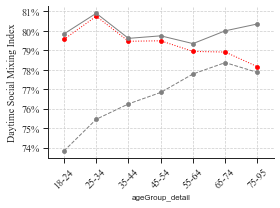

In [4]:
fig_age_average, ax_age_average = plot_city_average(temp_age, y="mixing_primary")


## Social Structure

Income, age, car ownership, transit-center distance, and household size profiles for `mixing_primary`.


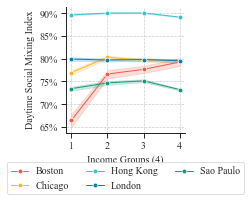

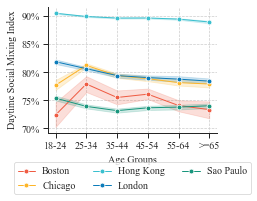

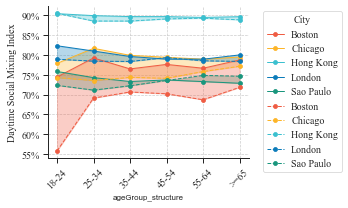

In [5]:
fig_income, ax_income = plot_line(
    temp_income,
    x="hhIncomeQ_4",
    order=["1", "2", "3", "4"],
    y="mixing_primary",
    figsize=figsize_dict["hhIncomeQ_4"],
)

fig_age_city, ax_age_city = plot_line(
    temp_age_city,
    x="ageGroup_structure",
    order=agegroup_order_structure_adult,
    y="mixing_primary",
    figsize=figsize_dict["ageGroup_structure"],
)

fig_age_employment, ax_age_employment = plot_age_employment_gap(
    temp_age_city[(temp_age_city["age"] > 17) & (temp_age_city["age"] < 85)].reset_index(drop=True)
)


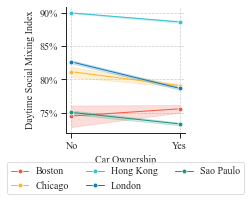

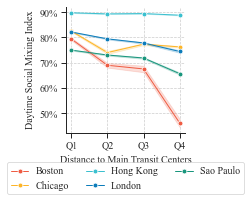

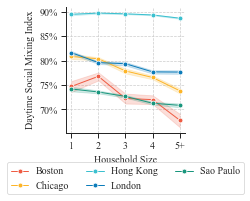

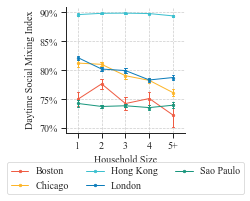

In [6]:
fig_car, ax_car = plot_line(
    temp_car,
    x="with_car_label",
    order=["No", "Yes"],
    y="mixing_primary",
    figsize=figsize_dict["with_car_label"],
)

fig_distance, ax_distance = plot_line(
    temp_distance,
    x="home_dist_center_poly_cat",
    order=["Q1", "Q2", "Q3", "Q4"],
    y="mixing_primary",
    figsize=figsize_dict["home_dist_center_poly_cat"],
)

fig_hhsize, ax_hhsize = plot_line(
    temp_hhsize,
    x="hh_mem_class",
    order=["1", "2", "3", "4", "5+"],
    y="mixing_primary",
    figsize=figsize_dict["hh_mem_class"],
)

fig_adult_hhsize, ax_adult_hhsize = plot_point(
    df_adult,
    x="hh_mem_class",
    order=["1", "2", "3", "4", "5+"],
    y="mixing_primary",
    figsize=figsize_dict["hh_mem_class"],
)


## Parenthood and Gender

Parenthood by age and by gender, using the adult subsets from the social-structure notebook.


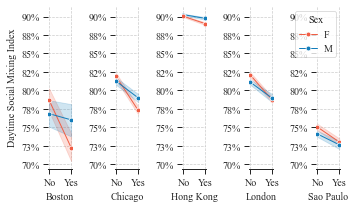

: 

In [ ]:
fig_parenthood_gender, axes_parenthood_gender = plot_parenthood_by_gender(df_adult_young)
